In [1]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from collections import Counter
from textblob import Word

In [2]:
data = pd.read_csv('youtoxic_english_1000.csv')
data.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [3]:
data.columns

Index(['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat',
       'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist',
       'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate',
       'IsRadicalism'],
      dtype='object')

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/zeto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/zeto/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/zeto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zeto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [6]:
data['Clean_Tokens'] = data['Text'].apply(clean_text)

In [7]:
lemmatizer_nltk = WordNetLemmatizer()

def lemmatize_nltk(tokens):
    return [lemmatizer_nltk.lemmatize(token) for token in tokens]

data['Lemmatized_NLTK'] = data['Clean_Tokens'].apply(lemmatize_nltk)

In [8]:
def lemmatize_textblob(tokens):
    return [Word(token).lemmatize() for token in tokens]

data['Lemmatized_TextBlob'] = data['Clean_Tokens'].apply(lemmatize_textblob)

In [9]:
porter = PorterStemmer()

def stem_porter(tokens):
    return [porter.stem(token) for token in tokens]

data['Stem_Porter'] = data['Clean_Tokens'].apply(stem_porter)

In [10]:
snowball = SnowballStemmer('english')

def stem_snowball(tokens):
    return [snowball.stem(token) for token in tokens]

data['Stem_Snowball'] = data['Clean_Tokens'].apply(stem_snowball)

In [11]:
toxic = data[data['IsToxic'] == True]
non_toxic = data[data['IsToxic'] == False]

In [12]:
def get_word_freq(tokens_list):
    all_tokens = []
    for tokens in tokens_list:
        all_tokens.extend(tokens)
    return Counter(all_tokens)

In [13]:
def plot_bar(freq_dict, title):
    most_common = freq_dict.most_common(20)
    words = [word for word, freq in most_common]
    frequencies = [freq for word, freq in most_common]
    
    plt.figure(figsize=(10,8))
    plt.barh(words[::-1], frequencies[::-1], color='skyblue')
    plt.xlabel('Частота')
    plt.title(title)
    plt.show()

In [14]:
def plot_wordcloud(freq_dict, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

In [36]:
def plot_bar_comparison(freq_toxic, freq_non_toxic, method_name):
    _, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    most_common_toxic = freq_toxic.most_common(20)
    words_toxic = [word for word, _ in most_common_toxic]
    frequencies_toxic = [freq for _, freq in most_common_toxic]
    
    axes[0].barh(words_toxic[::-1], frequencies_toxic[::-1], color='salmon')
    axes[0].set_xlabel('Частота')
    axes[0].set_title(f'Токсичные комментарии ({method_name})')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    most_common_non_toxic = freq_non_toxic.most_common(20)
    words_non_toxic = [word for word, _ in most_common_non_toxic]
    frequencies_non_toxic = [freq for _, freq in most_common_non_toxic]
    
    axes[1].barh(words_non_toxic[::-1], frequencies_non_toxic[::-1], color='skyblue')
    axes[1].set_xlabel('Частота')
    axes[1].set_title(f'Нетоксичные комментарии ({method_name})')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_wordcloud_comparison(freq_toxic, freq_non_toxic, method_name):
    _, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    wordcloud_toxic = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_toxic)
    axes[0].imshow(wordcloud_toxic, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(f'Облако слов для токсичных комментариев ({method_name})', fontsize=15)
    
    wordcloud_non_toxic = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_non_toxic)
    axes[1].imshow(wordcloud_non_toxic, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title(f'Облако слов для нетоксичных комментариев ({method_name})', fontsize=15)
    
    plt.tight_layout()
    plt.show()

In [16]:
freq_toxic_nltk = get_word_freq(toxic['Lemmatized_NLTK'])
freq_non_toxic_nltk = get_word_freq(non_toxic['Lemmatized_NLTK'])

freq_toxic_textblob = get_word_freq(toxic['Lemmatized_TextBlob'])
freq_non_toxic_textblob = get_word_freq(non_toxic['Lemmatized_TextBlob'])

freq_toxic_porter = get_word_freq(toxic['Stem_Porter'])
freq_non_toxic_porter = get_word_freq(non_toxic['Stem_Porter'])

freq_toxic_snowball = get_word_freq(toxic['Stem_Snowball'])
freq_non_toxic_snowball = get_word_freq(non_toxic['Stem_Snowball'])

In [17]:
methods = {
    'Лемматизация NLTK': (freq_toxic_nltk, freq_non_toxic_nltk),
    'Лемматизация TextBlob': (freq_toxic_textblob, freq_non_toxic_textblob),
    'Стемминг Porter': (freq_toxic_porter, freq_non_toxic_porter),
    'Стемминг Snowball': (freq_toxic_snowball, freq_non_toxic_snowball)
}

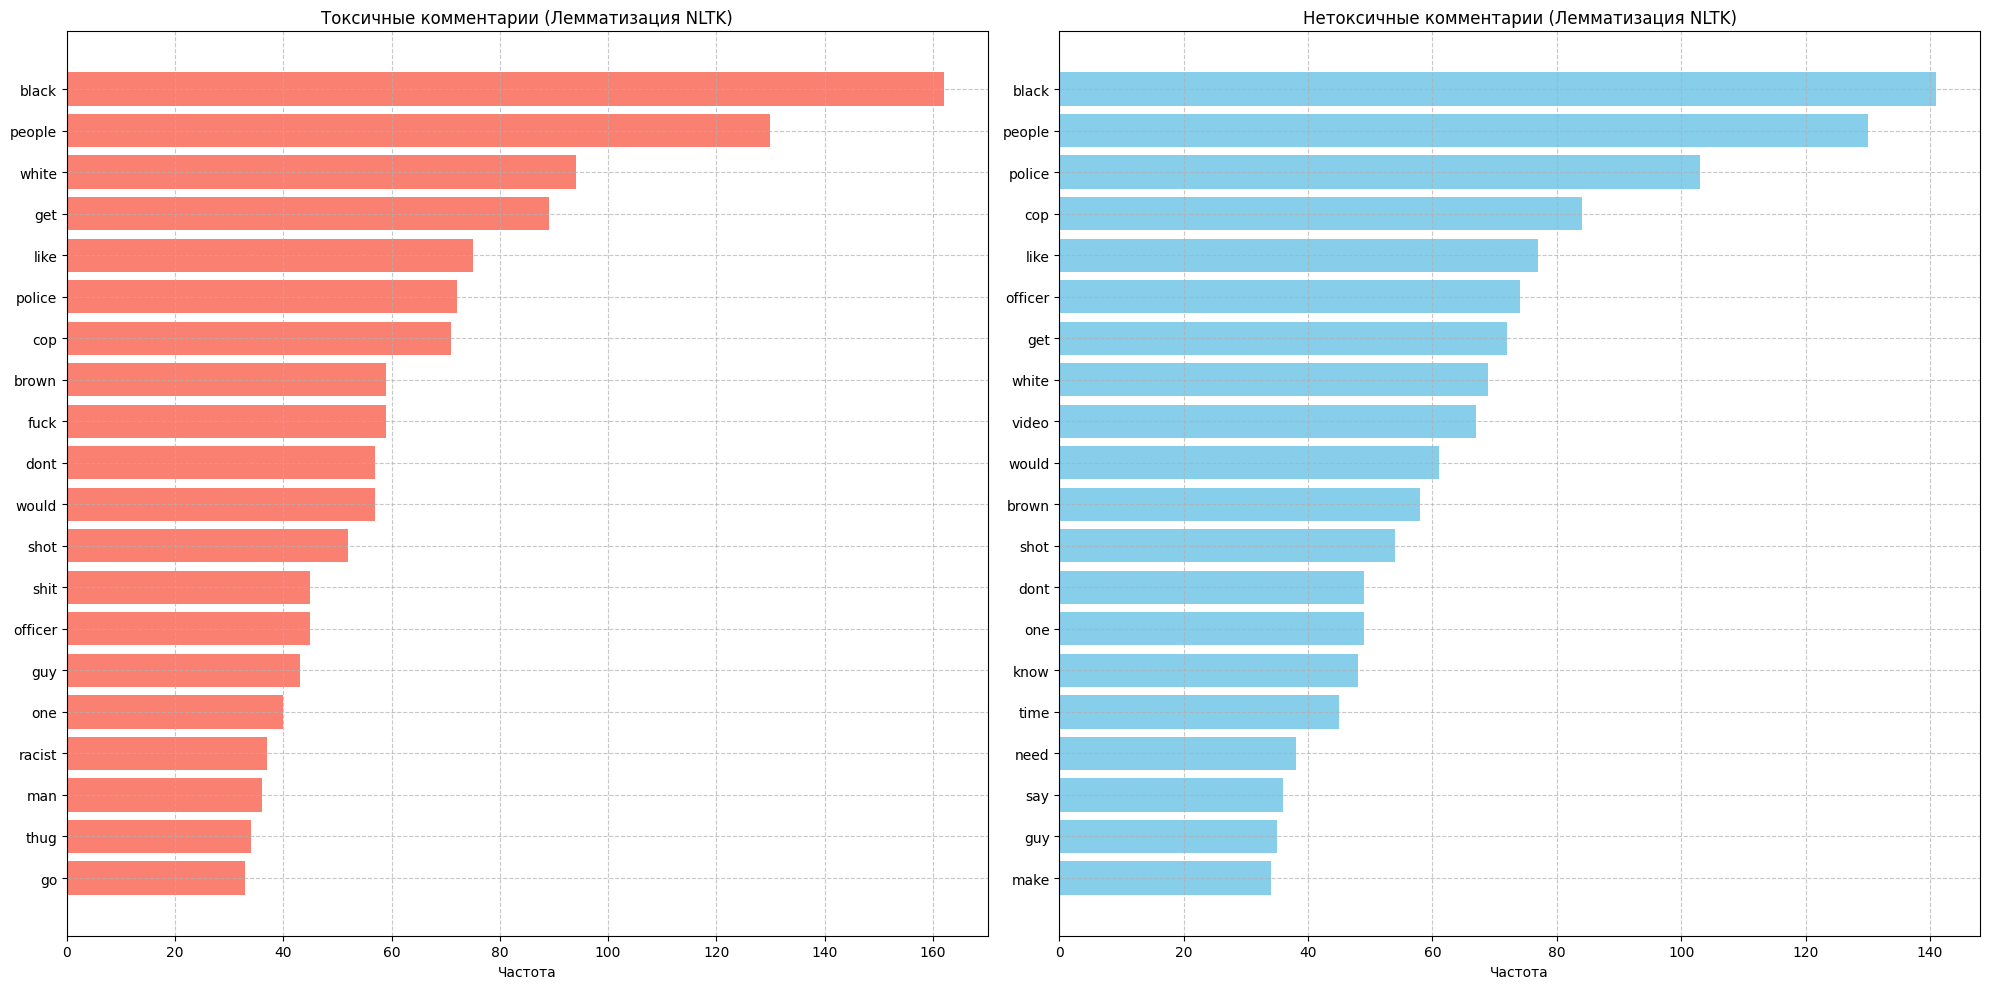

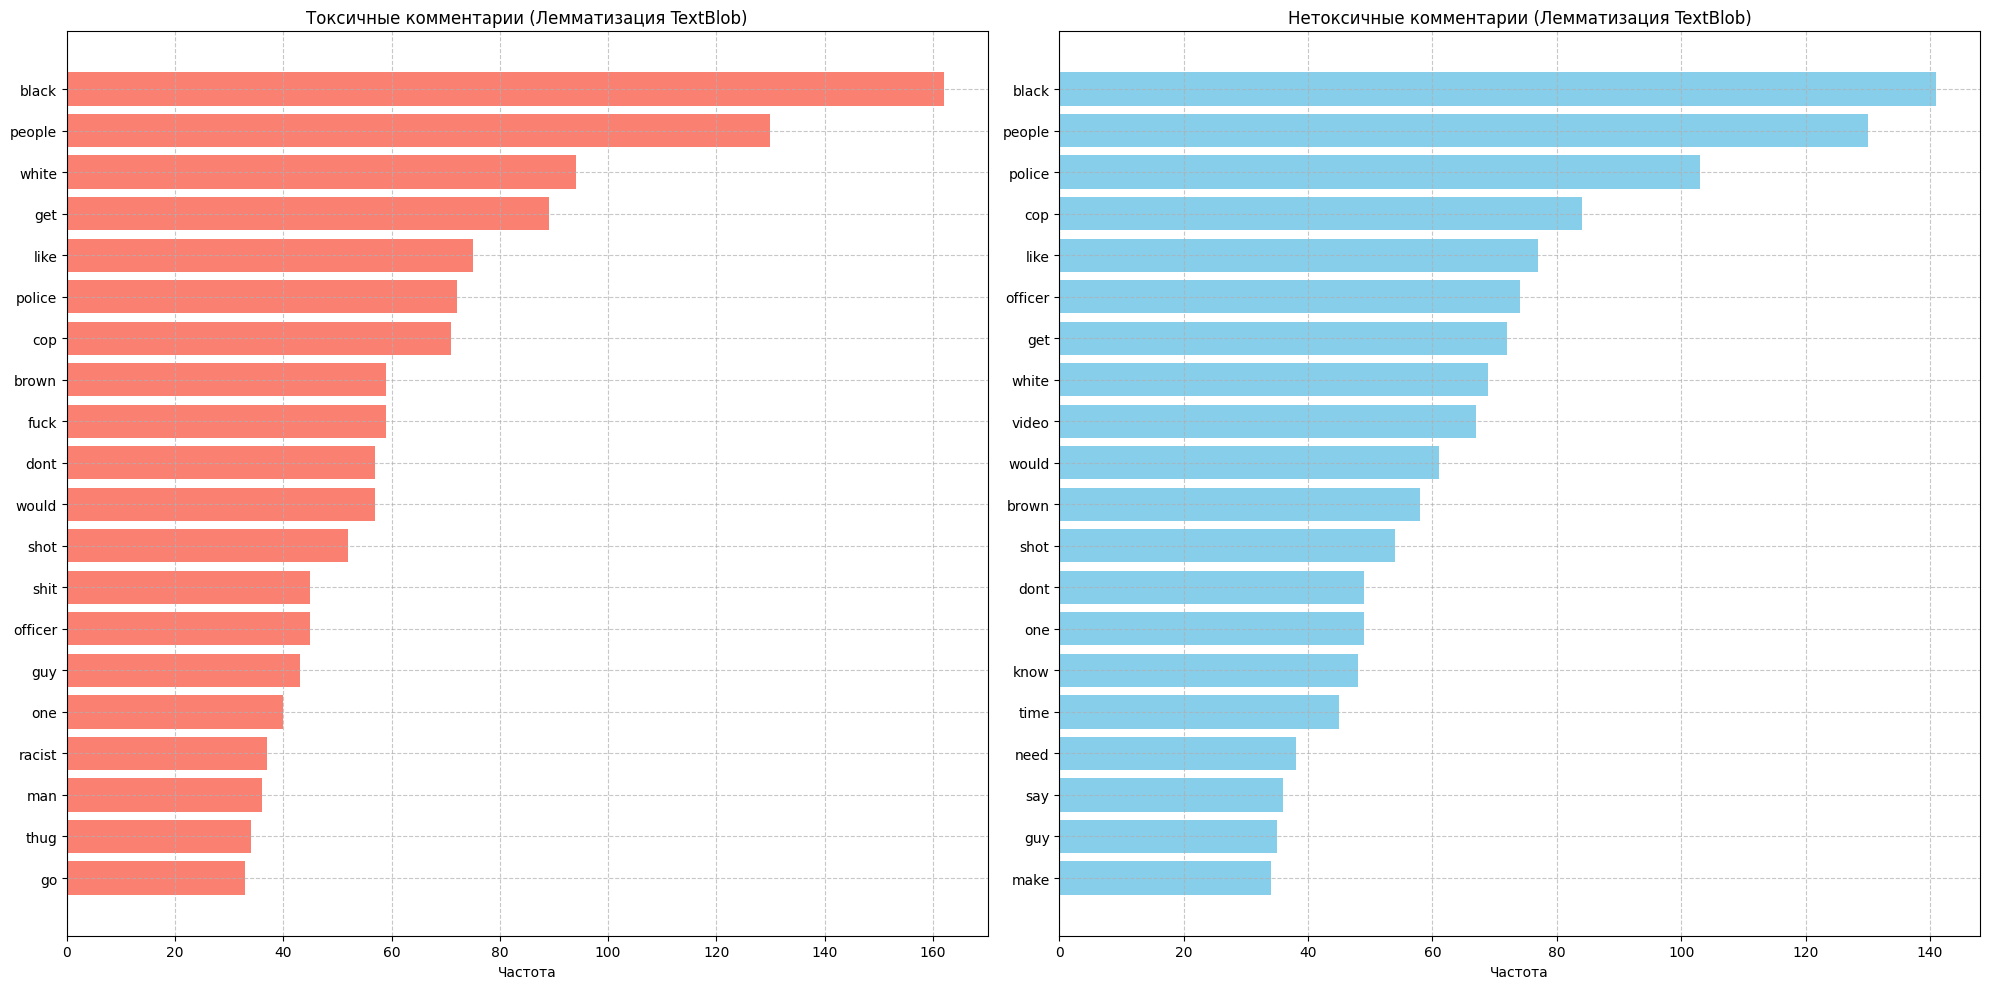

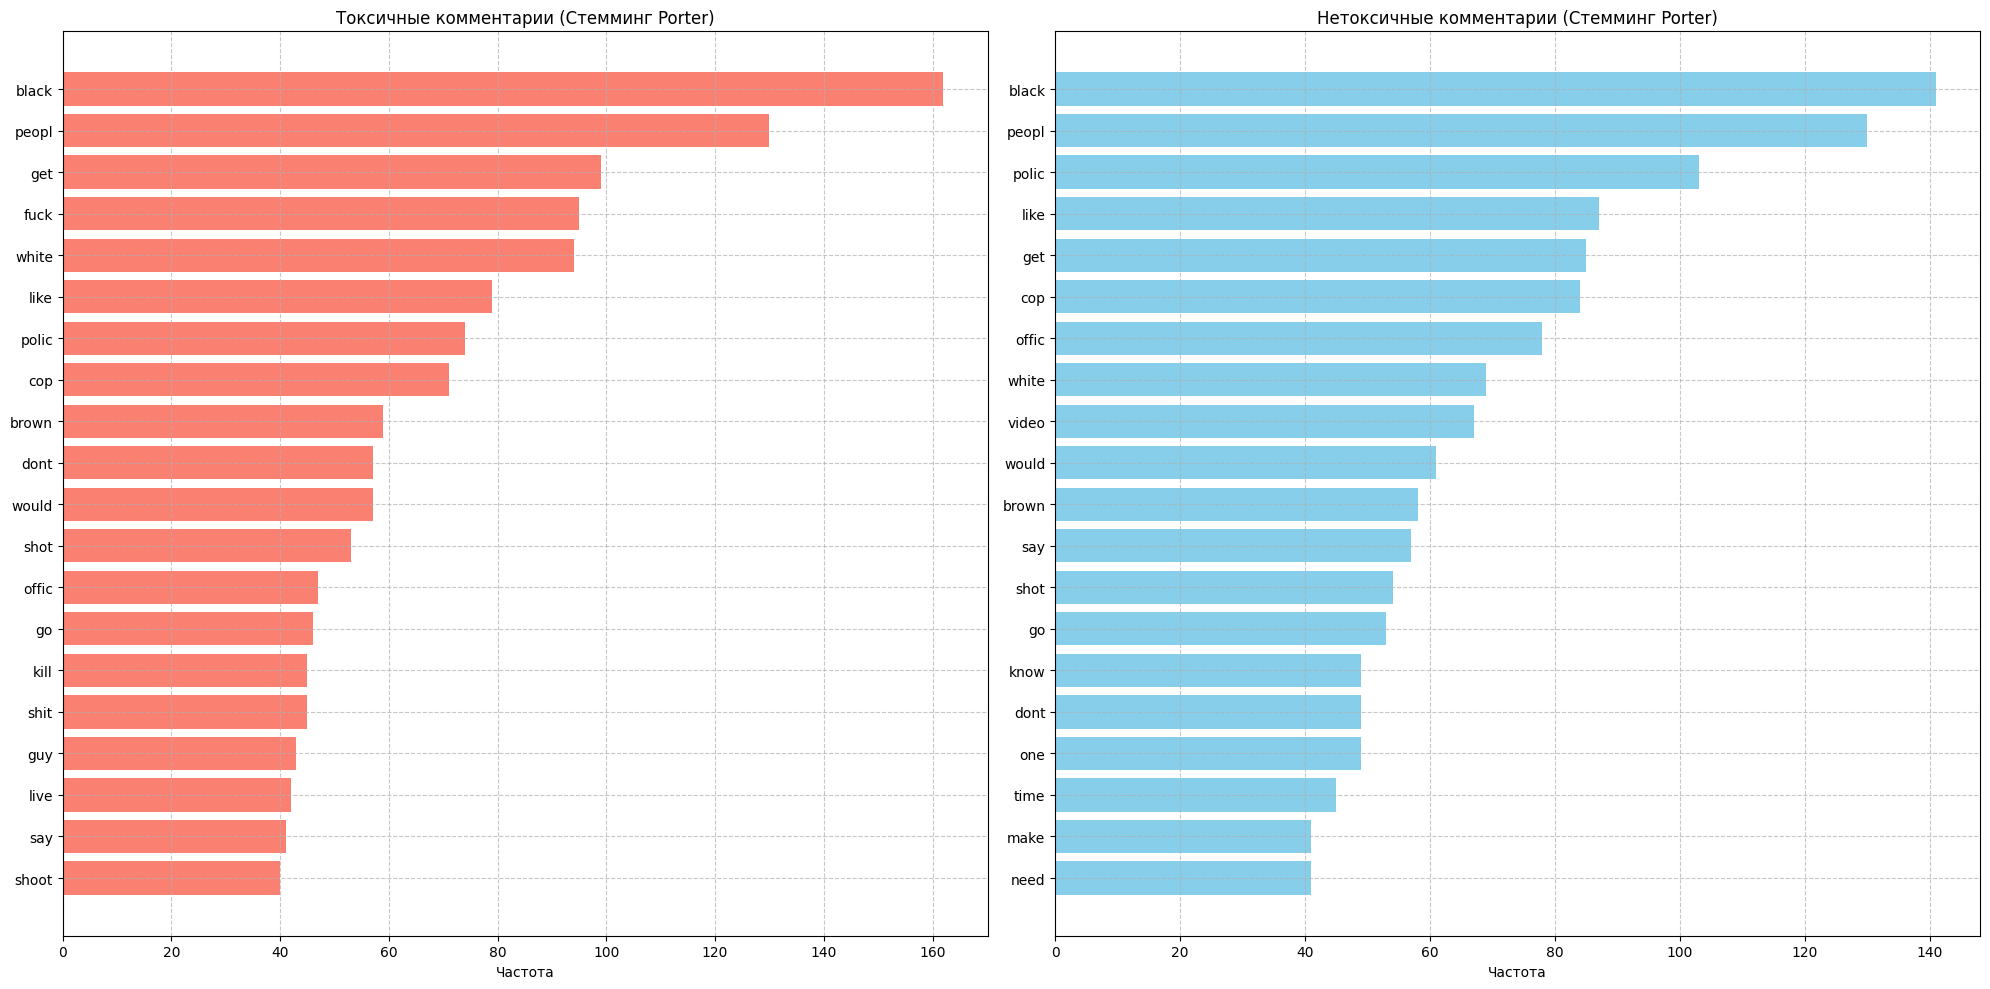

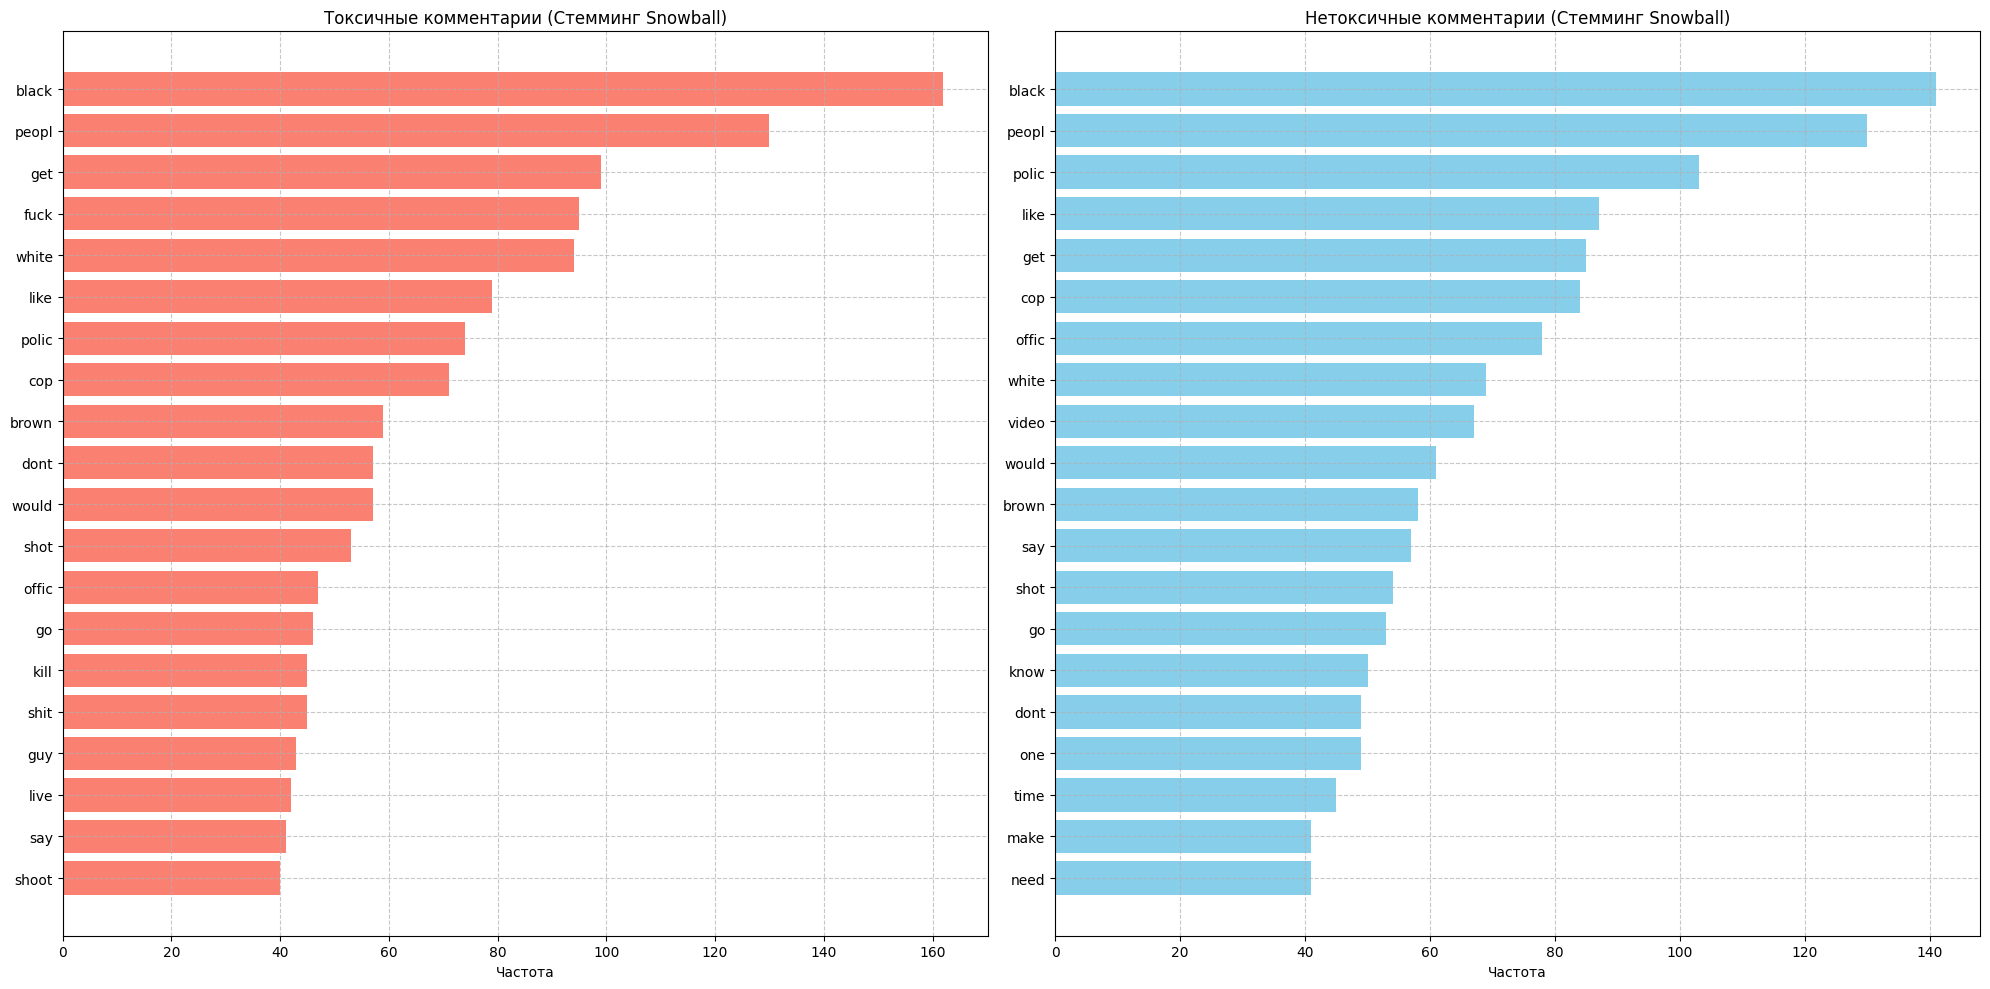

In [37]:
for method_name, (freq_toxic, freq_non_toxic) in methods.items():
    plot_bar_comparison(freq_toxic, freq_non_toxic, method_name)

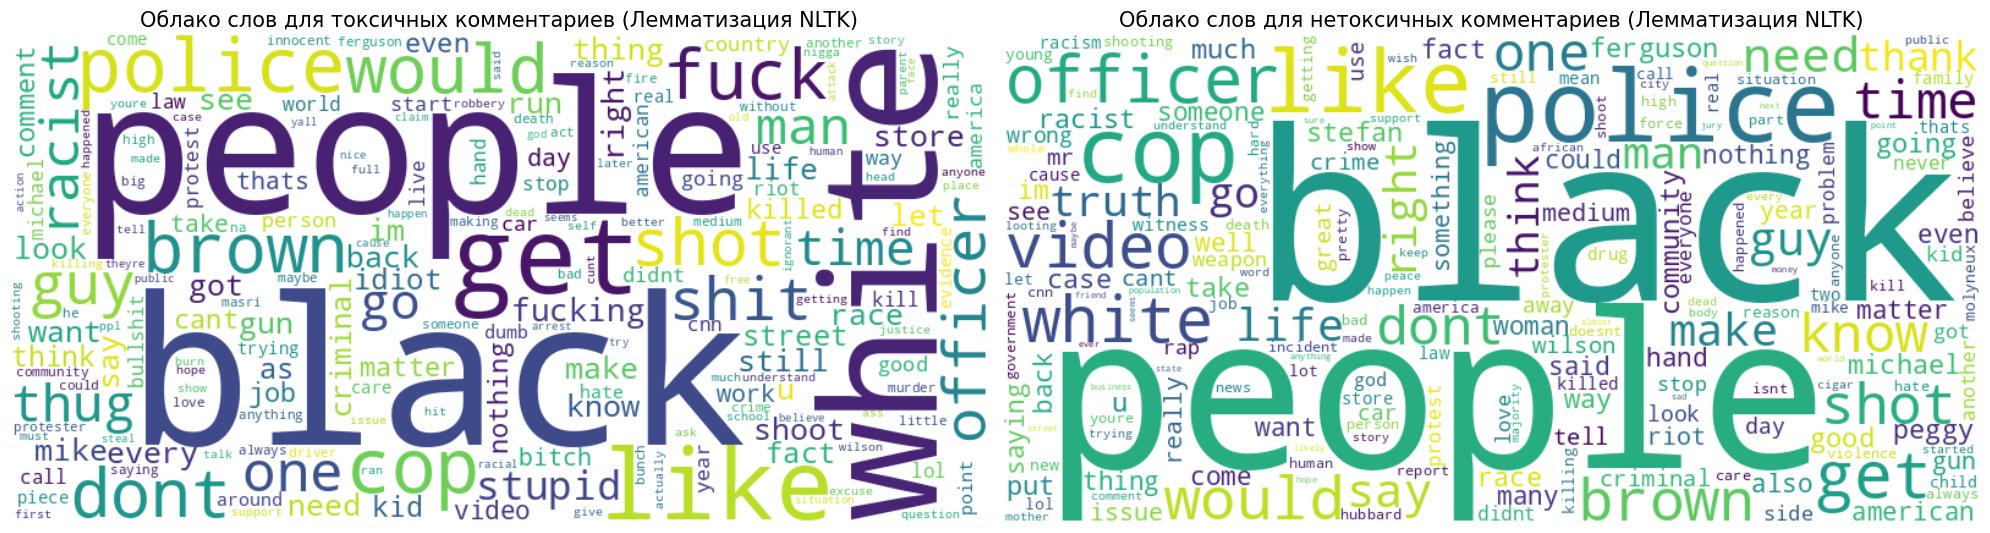

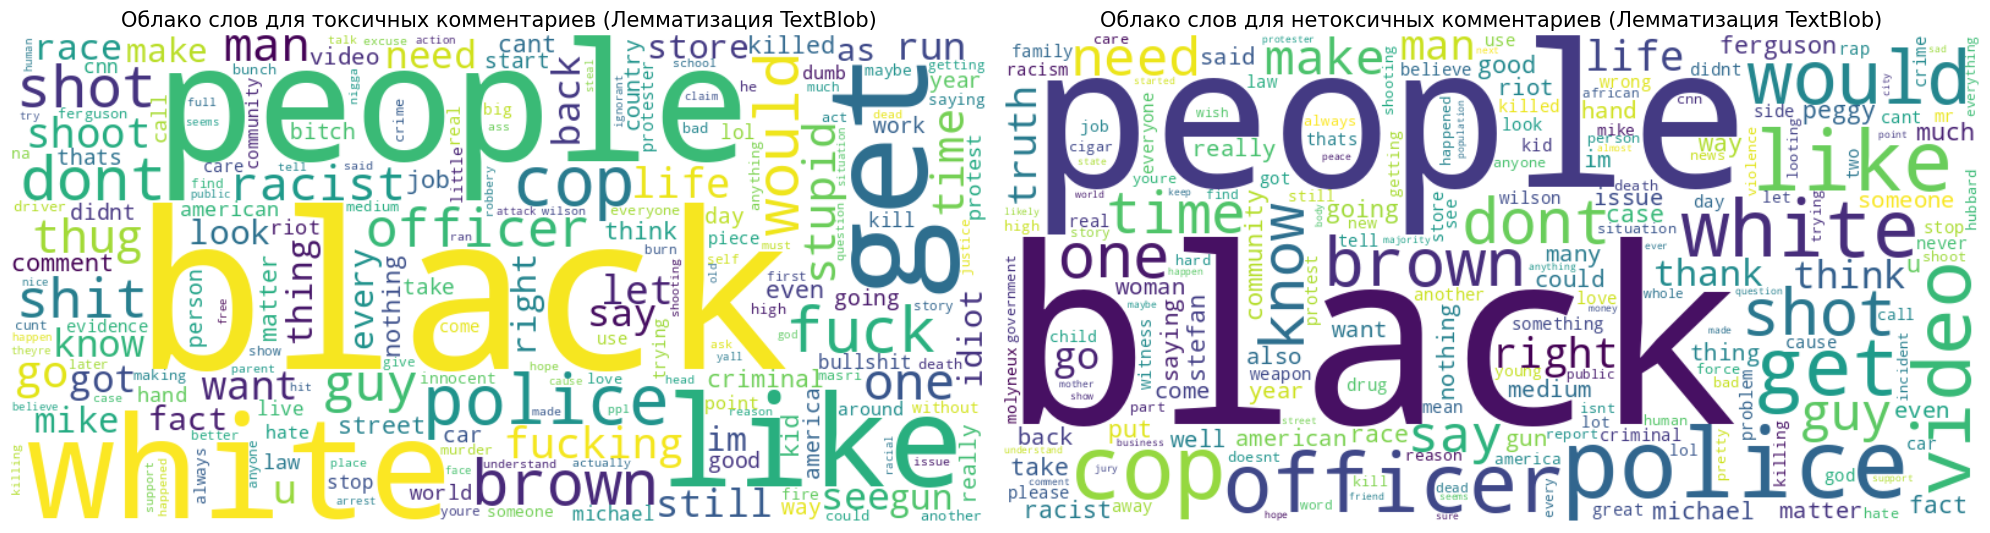

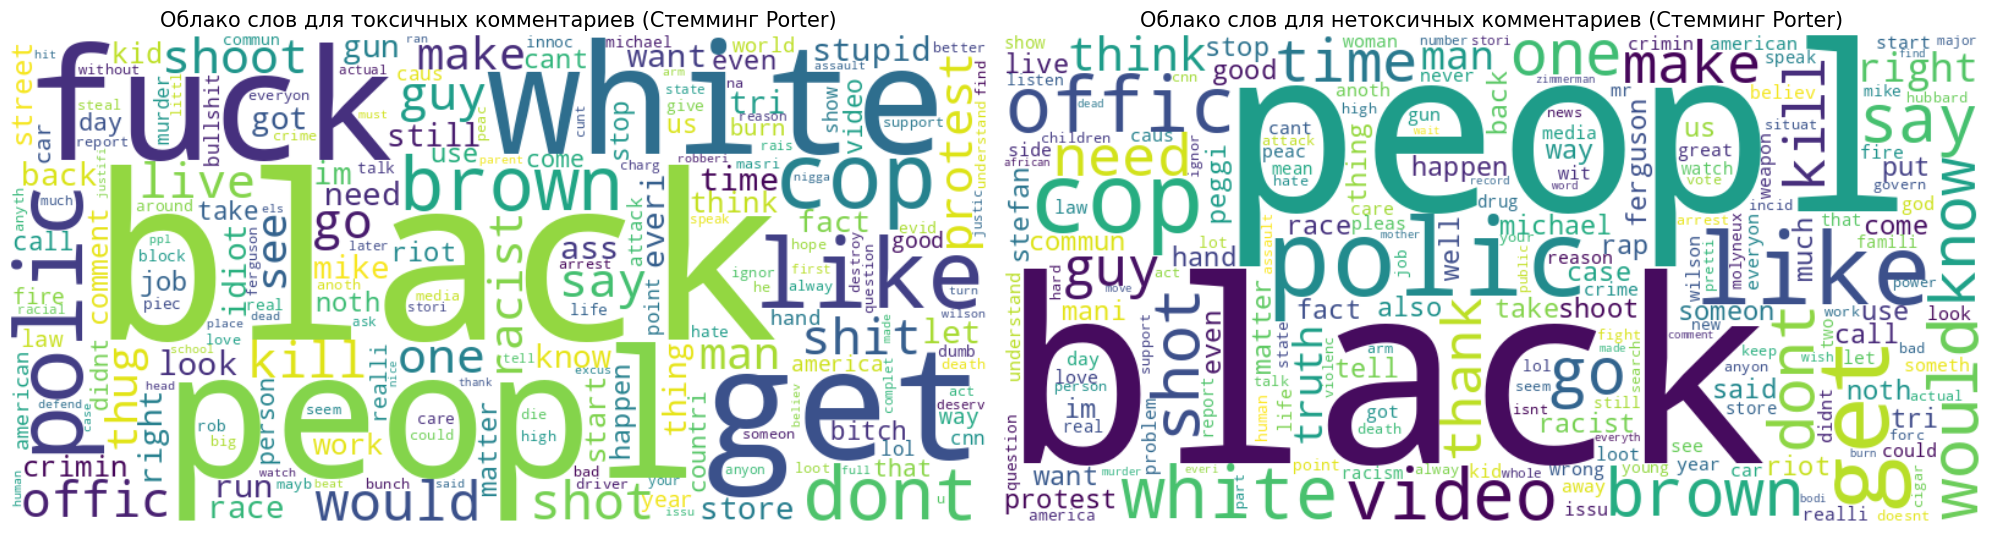

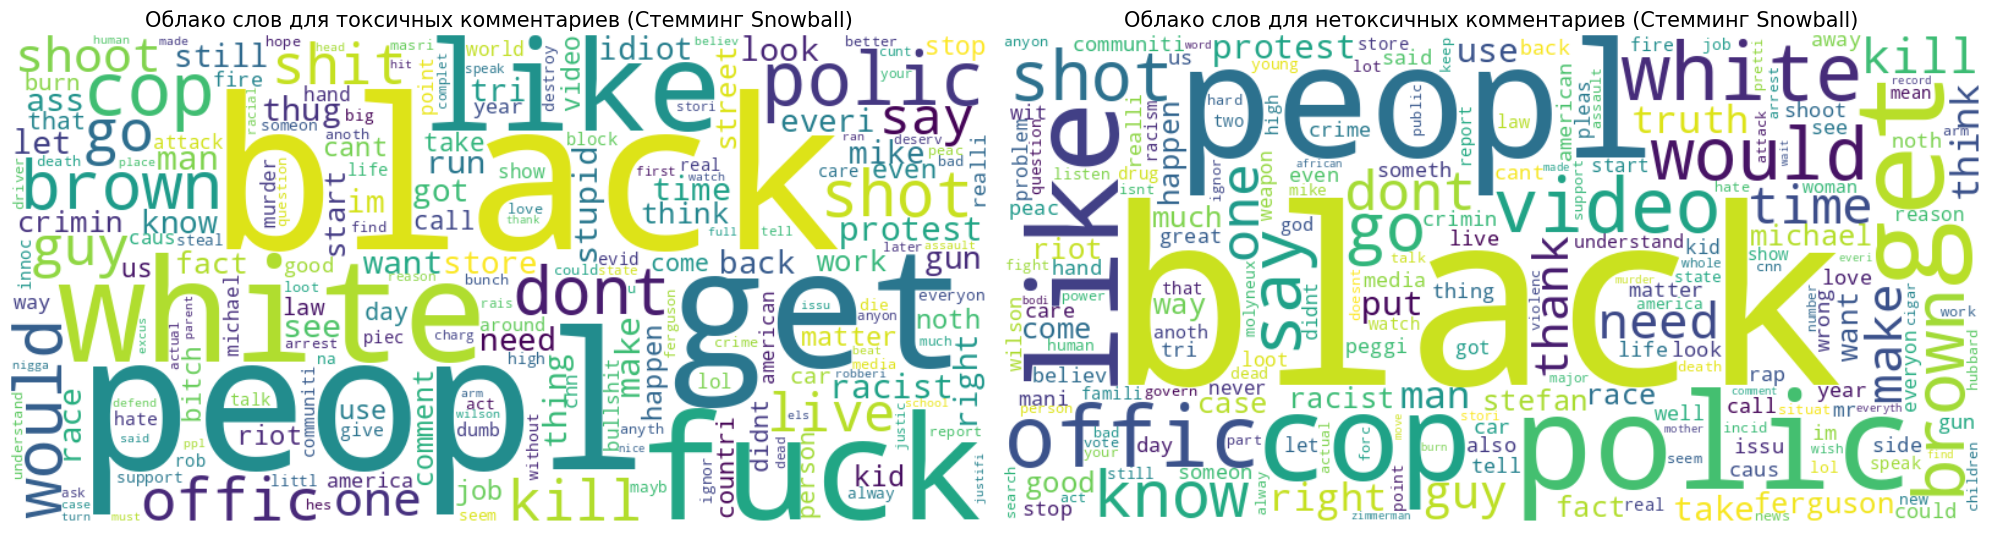

In [19]:
for method_name, (freq_toxic, freq_non_toxic) in methods.items():
    plot_wordcloud_comparison(freq_toxic, freq_non_toxic, method_name)

In [33]:
from tabulate import tabulate 

In [34]:
def display_examples(data, num_examples=10, max_words=10):
    examples = []
    for i in range(num_examples):
        original = ' '.join(data['Clean_Tokens'].iloc[i][:max_words]) + ('...' if len(data['Clean_Tokens'].iloc[i]) > max_words else '')
        lemmatized_nltk = ' '.join(data['Lemmatized_NLTK'].iloc[i][:max_words]) + ('...' if len(data['Lemmatized_NLTK'].iloc[i]) > max_words else '')
        lemmatized_textblob = ' '.join(data['Lemmatized_TextBlob'].iloc[i][:max_words]) + ('...' if len(data['Lemmatized_TextBlob'].iloc[i]) > max_words else '')
        stem_porter = ' '.join(data['Stem_Porter'].iloc[i][:max_words]) + ('...' if len(data['Stem_Porter'].iloc[i]) > max_words else '')
        stem_snowball = ' '.join(data['Stem_Snowball'].iloc[i][:max_words]) + ('...' if len(data['Stem_Snowball'].iloc[i]) > max_words else '')
        
        examples.append([
            original,
            lemmatized_nltk,
            lemmatized_textblob,
            stem_porter,
            stem_snowball
        ])
    
    headers = ['Original', 'Lemmatized NLTK', 'Lemmatized TextBlob', 'Stem Porter', 'Stem Snowball']
    print(tabulate(examples, headers=headers, tablefmt='grid'))

def count_unique_words(freq_dict):
    return len(freq_dict)


# Шаг 5: Сравнение результатов и обсуждение

In [35]:
print("# Примеры преобразований слов:")
display_examples(data, num_examples=10)

# Примеры преобразований слов:
+----------------------------------------------------------------------------+----------------------------------------------------------------------------+----------------------------------------------------------------------------+-------------------------------------------------------------------+-------------------------------------------------------------------+
| Original                                                                   | Lemmatized NLTK                                                            | Lemmatized TextBlob                                                        | Stem Porter                                                       | Stem Snowball                                                     |
+============================================================================+============================================================================+============================================================================

In [29]:
unique_words = {
    'Лемматизация NLTK': (count_unique_words(freq_toxic_nltk), count_unique_words(freq_non_toxic_nltk)),
    'Лемматизация TextBlob': (count_unique_words(freq_toxic_textblob), count_unique_words(freq_non_toxic_textblob)),
    'Стемминг Porter': (count_unique_words(freq_toxic_porter), count_unique_words(freq_non_toxic_porter)),
    'Стемминг Snowball': (count_unique_words(freq_toxic_snowball), count_unique_words(freq_non_toxic_snowball))
}

In [31]:
print("# Количество уникальных слов после обработки:")
print(f'{"Метод обработки":<25} {"Токсичные":<15} {"Нетоксичные":<15}')
print('-' * 55)
for method, (toxic_count, non_toxic_count) in unique_words.items():
    print(f'{method:<25} {toxic_count:<15} {non_toxic_count:<15}')


# Количество уникальных слов после обработки:
Метод обработки           Токсичные       Нетоксичные    
-------------------------------------------------------
Лемматизация NLTK         2631            2752           
Лемматизация TextBlob     2631            2752           
Стемминг Porter           2296            2350           
Стемминг Snowball         2285            2327           


In [27]:
print("# Анализ количества уникальных слов:")
for method, (toxic_count, non_toxic_count) in unique_words.items():
    print(f"{method}:")
    print(f"  - Токсичные комментарии имеют {toxic_count} уникальных слов.")
    print(f"  - Нетоксичные комментарии имеют {non_toxic_count} уникальных слов.\n")


# Анализ количества уникальных слов:
Лемматизация NLTK:
  - Токсичные комментарии имеют 2631 уникальных слов.
  - Нетоксичные комментарии имеют 2752 уникальных слов.

Лемматизация TextBlob:
  - Токсичные комментарии имеют 2631 уникальных слов.
  - Нетоксичные комментарии имеют 2752 уникальных слов.

Стемминг Porter:
  - Токсичные комментарии имеют 2296 уникальных слов.
  - Нетоксичные комментарии имеют 2350 уникальных слов.

Стемминг Snowball:
  - Токсичные комментарии имеют 2285 уникальных слов.
  - Нетоксичные комментарии имеют 2327 уникальных слов.



In [26]:
print("# Пропорция методов обработки:")
for method, (freq_toxic, freq_non_toxic) in methods.items():
    total_toxic = sum(freq_toxic.values())
    total_non_toxic = sum(freq_non_toxic.values())
    unique_toxic = count_unique_words(freq_toxic)
    unique_non_toxic = count_unique_words(freq_non_toxic)
    print(f"{method}:")
    print(f"  - Токсичные: {unique_toxic} уникальных слов из {total_toxic} слов (разнообразие: {unique_toxic / total_toxic:.2%})")
    print(f"  - Нетоксичные: {unique_non_toxic} уникальных слов из {total_non_toxic} слов (разнообразие: {unique_non_toxic / total_non_toxic:.2%})\n")

# Пропорция методов обработки:
Лемматизация NLTK:
  - Токсичные: 2631 уникальных слов из 8368 слов (разнообразие: 31.44%)
  - Нетоксичные: 2752 уникальных слов из 8960 слов (разнообразие: 30.71%)

Лемматизация TextBlob:
  - Токсичные: 2631 уникальных слов из 8368 слов (разнообразие: 31.44%)
  - Нетоксичные: 2752 уникальных слов из 8960 слов (разнообразие: 30.71%)

Стемминг Porter:
  - Токсичные: 2296 уникальных слов из 8368 слов (разнообразие: 27.44%)
  - Нетоксичные: 2350 уникальных слов из 8960 слов (разнообразие: 26.23%)

Стемминг Snowball:
  - Токсичные: 2285 уникальных слов из 8368 слов (разнообразие: 27.31%)
  - Нетоксичные: 2327 уникальных слов из 8960 слов (разнообразие: 25.97%)

